In [17]:
# CELL 0 — Import + Load 1 record 2xx trực tiếp từ WFDB (MIT-BIH)

# ĐỊNH NGHĨA (load data WFDB):
# - Là gì? Đọc ECG từ database MIT-BIH qua thư viện wfdb (tải/đọc tự động).
# - Tác dụng? Có ngay x_raw (ECG), fs (tần số lấy mẫu) để xử lý.
# - Nếu không? Bạn phải tự tải .dat/.hea/.atr và tự quản lý đường dẫn.

import numpy as np
import matplotlib.pyplot as plt
import wfdb
import sys
from scipy.signal import butter, sosfiltfilt, iirnotch, filtfilt, welch, medfilt

# Lấy danh sách record 2xx và chọn 1 record để demo
all_records = wfdb.get_record_list("mitdb")
records_2xx = [r for r in all_records if r.startswith("2")]

RECORD_ID = "203" if "203" in records_2xx else records_2xx[0]  # đổi nếu bạn muốn

# Load trực tiếp từ WFDB (pn_dir='mitdb' sẽ tự tải nếu máy bạn có internet)
record = wfdb.rdrecord(RECORD_ID, pn_dir="mitdb")

fs = float(record.fs)                 # Hz
sig = record.p_signal                 # shape (N, n_channels), đơn vị vật lý (thường mV)
ch_names = list(record.sig_name)

# Chọn kênh MLII nếu có, không thì lấy kênh đầu
ch = ch_names.index("MLII") if "MLII" in ch_names else 0
x_raw = sig[:, ch].astype(np.float64)

t = np.arange(len(x_raw)) / fs

print(f"Loaded record={RECORD_ID} | fs={fs} Hz | channel={ch_names[ch]} | N={len(x_raw)} samples")


Loaded record=203 | fs=360.0 Hz | channel=MLII | N=650000 samples


In [18]:
# CELL 1 — Thuật toán Apply band-pass filter (0.5–40 Hz)

# ĐỊNH NGHĨA (Band-pass):
# - Là gì? Bộ lọc chỉ giữ tần số trong [0.5, 40] Hz, loại bỏ <0.5 (drift) và >40 (nhiễu cao tần).
# - Tác dụng? Làm ECG “gọn” cho QRS/HRV: bớt trôi nền + bớt nhiễu cơ/EMG.
# - Nếu không? R-peak dễ sai, PSD/bandpower bị méo, nhìn tín hiệu “rác”.
#
# CÔNG THỨC (khái niệm):
# - Thiết kế Butterworth IIR: H(z) được xác định bởi hệ số lọc.
# - Áp dụng zero-phase: y = sosfiltfilt(sos, x) (lọc 2 chiều để không lệch pha).
#
# INPUT: x (1D ECG), fs (Hz)
# OUTPUT: y (đã lọc), sos (tham số filter)

def bandpass_filter(x, fs, low_hz=0.5, high_hz=40.0, order=4):
    sos = butter(order, [low_hz, high_hz], btype="bandpass", fs=fs, output="sos")
    y = sosfiltfilt(sos, x)  # zero-phase
    return y, sos

x_bandpassed, bp_sos = bandpass_filter(x_raw, fs, low_hz=0.5, high_hz=40.0, order=4)


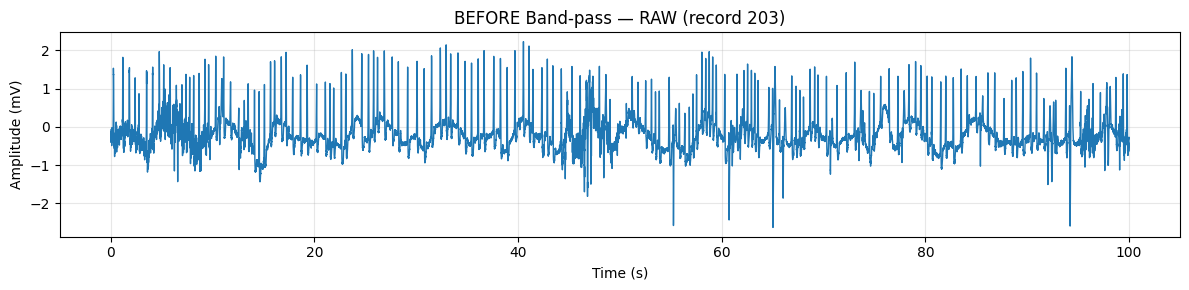

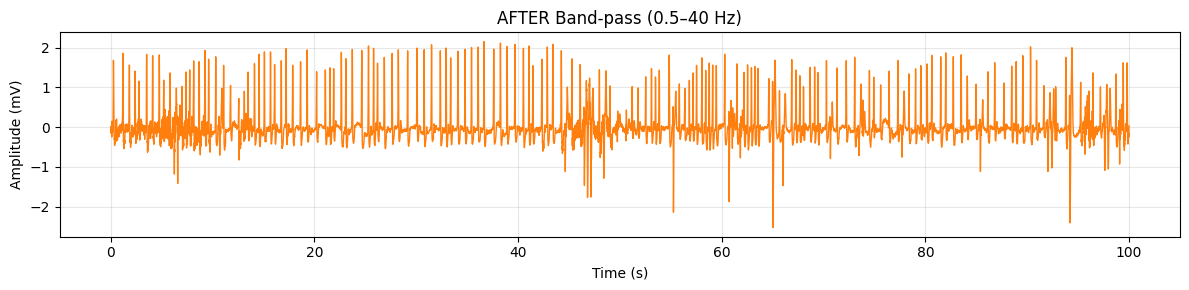

In [19]:
# CELL 2 — Visualize BEFORE và AFTER (band-pass) (2 hình riêng, màu khác nhau)

def plot_segment(x, fs, start_s=0, win_s=10, title="", color="tab:blue"):
    i0 = int(start_s * fs)
    i1 = int((start_s + win_s) * fs)
    tt = np.arange(i0, i1) / fs

    plt.figure(figsize=(12, 3))
    plt.plot(tt, x[i0:i1], color=color, linewidth=1.0)
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude (mV)")
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_segment(
    x_raw, fs,
    start_s=0, win_s=100,
    title=f"BEFORE Band-pass — RAW (record {RECORD_ID})",
    color="tab:blue"
)

plot_segment(
    x_bandpassed, fs,
    start_s=0, win_s=100,
    title="AFTER Band-pass (0.5–40 Hz)",
    color="tab:orange"
)


In [20]:
# CELL 3 — Thuật toán Remove baseline wander

# ĐỊNH NGHĨA (Baseline wander):
# - Là gì? Dao động đường nền chậm (thường do hô hấp, chuyển động điện cực), tần số rất thấp.
# - Tác dụng? Kéo baseline về ~0, giúp đo ST/QRS ổn định, giảm false detection.
# - Nếu không? ECG bị “lên xuống” nền, threshold R-peak dễ trượt, feature biên độ sai.
#
# CÔNG THỨC (median filter 2 tầng — robust):
# - baseline = medfilt( medfilt(x, w1), w2 )
# - y = x - baseline
#
# INPUT: x (ECG), fs
# OUTPUT: y (đã khử trôi nền), baseline_est (đường nền ước lượng)

def _odd(n: int) -> int:
    n = int(n)
    if n < 3:
        n = 3
    return n if (n % 2 == 1) else (n + 1)

def remove_baseline_wander_median(x, fs, w1_s=0.2, w2_s=0.6):
    k1 = _odd(round(w1_s * fs))  # ~200 ms
    k2 = _odd(round(w2_s * fs))  # ~600 ms

    b1 = medfilt(x, kernel_size=k1)
    baseline = medfilt(b1, kernel_size=k2)

    y = x - baseline
    return y, baseline

# Thực tế: bạn có thể áp dụng trên raw hoặc bandpassed.
# Ở đây áp dụng lên x_bandpassed để pipeline “gọn” theo thứ tự cell.
x_baseline_removed, baseline_est = remove_baseline_wander_median(x_bandpassed, fs, w1_s=0.2, w2_s=0.6)


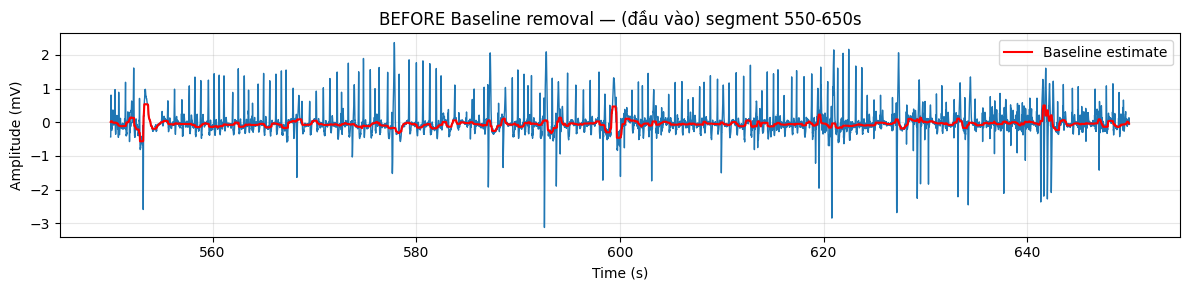

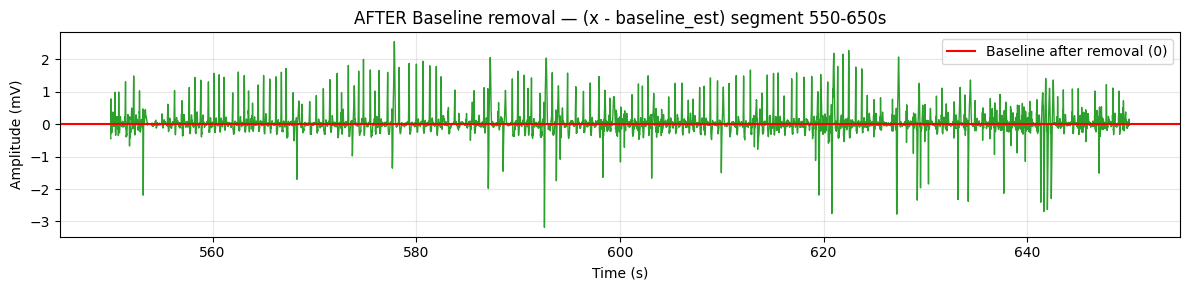

In [21]:
# CELL 4 — Visualize BEFORE và AFTER (baseline wander) (2 hình riêng, màu khác nhau)

# Chọn đoạn có baseline wander rõ hơn 
start_s = 550
win_s = 100

i0 = int(start_s * fs)
i1 = int((start_s + win_s) * fs)
tt = np.arange(i0, i1) / fs

plt.figure(figsize=(12, 3))
plt.plot(tt, x_bandpassed[i0:i1], color="tab:blue", linewidth=1.0)
plt.plot(tt, baseline_est[i0:i1], color="red", linewidth=1.5, label="Baseline estimate")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude (mV)")
plt.title(f"BEFORE Baseline removal — (đầu vào) segment {start_s}-{start_s+win_s}s")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# AFTER plot with baseline overlay 
plt.figure(figsize=(12, 3))
plt.plot(tt, x_baseline_removed[i0:i1], color="tab:green", linewidth=1.0)
plt.axhline(0, color="red", linewidth=1.5, label="Baseline after removal (0)")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude (mV)")
plt.title(f"AFTER Baseline removal — (x - baseline_est) segment {start_s}-{start_s+win_s}s")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [22]:
# CELL 5 — Thuật toán Remove power line interference (50/60 Hz)

# ĐỊNH NGHĨA (Power-line interference):
# - Là gì? Nhiễu sin tại 50 Hz (VN/EU) hoặc 60 Hz (US) + có thể có harmonic.
# - Tác dụng? Loại “gợn” đều đều trên ECG, tránh làm PSD/bandpower sai và làm rối peak detection.
# - Nếu không? Tín hiệu có ripple 50/60 Hz, nhìn “rung”, thống kê/phổ bị peak lớn tại 50/60.
#
# CÔNG THỨC (notch IIR):
# - iirnotch(f0, Q, fs) -> (b, a) của notch filter tại f0
# - y = filtfilt(b, a, x) để zero-phase (không lệch pha)
#
# INPUT: x, fs, mains_hz (None => tự detect), Q, n_harmonics
# OUTPUT: y_notched, mains_used, harmonics_applied

def detect_mains_freq(x, fs):
    f, P = welch(x, fs=fs, nperseg=min(4096, len(x)))

    def peak_near(target, bw=1.0):
        m = (f >= target - bw) & (f <= target + bw)
        return float(np.max(P[m])) if np.any(m) else 0.0

    p50 = peak_near(50.0, 1.0)
    p60 = peak_near(60.0, 1.0)
    return 50.0 if p50 >= p60 else 60.0

def remove_powerline_notch(x, fs, mains_hz=None, Q=30.0, n_harmonics=6):
    if mains_hz is None:
        mains_hz = 60

    y = x.astype(np.float64).copy()
    nyq = fs / 2.0
    used = []

    for k in range(1, n_harmonics + 1):
        f0 = mains_hz * k
        if f0 >= nyq:
            break
        b, a = iirnotch(w0=f0, Q=Q, fs=fs)
        y = filtfilt(b, a, y)  # zero-phase
        used.append(f0)

    return y, mains_hz, used


x_notched, mains_used, harmonics_used = remove_powerline_notch(
    x_baseline_removed, fs, mains_hz=None, Q=30.0, n_harmonics=6
)

print(f"Detected mains = {mains_used} Hz | Notched frequencies = {harmonics_used}")


Detected mains = 60 Hz | Notched frequencies = [60, 120]


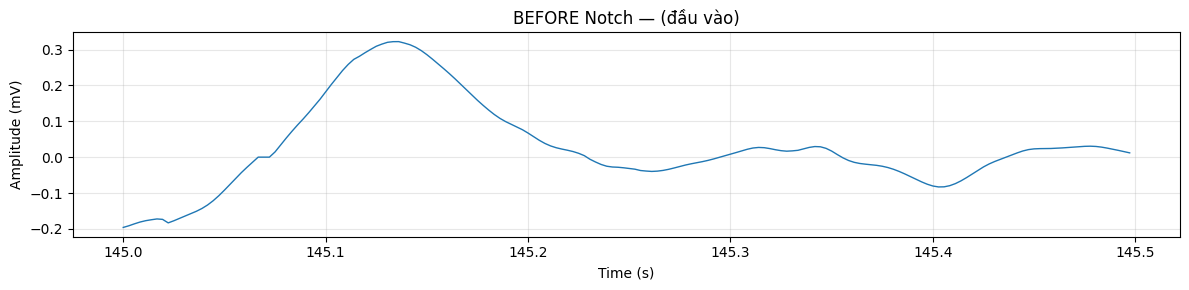

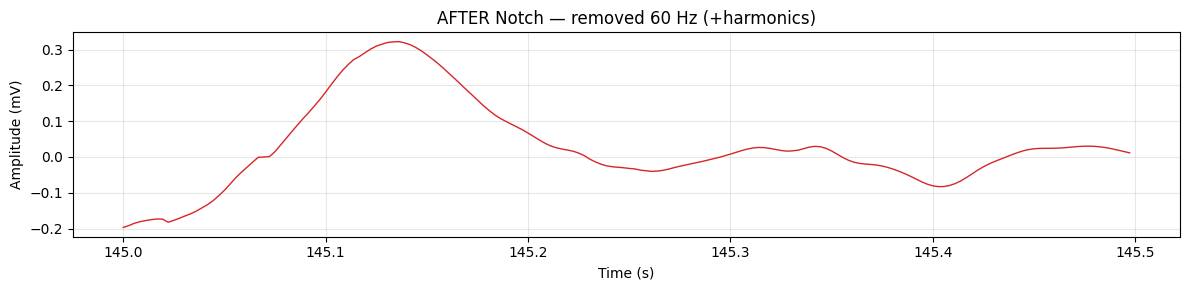

In [23]:
# CELL 6 — Visualize BEFORE và AFTER (power-line notch) (2 hình riêng, màu khác nhau)

plot_segment(
    x_baseline_removed, fs,
    start_s=145, win_s=0.5,
    title="BEFORE Notch — (đầu vào)",
    color="tab:blue"
)

plot_segment(
    x_notched, fs,
    start_s=145, win_s=0.5,
    title=f"AFTER Notch — removed {int(mains_used)} Hz (+harmonics)",
    color="tab:red"
)

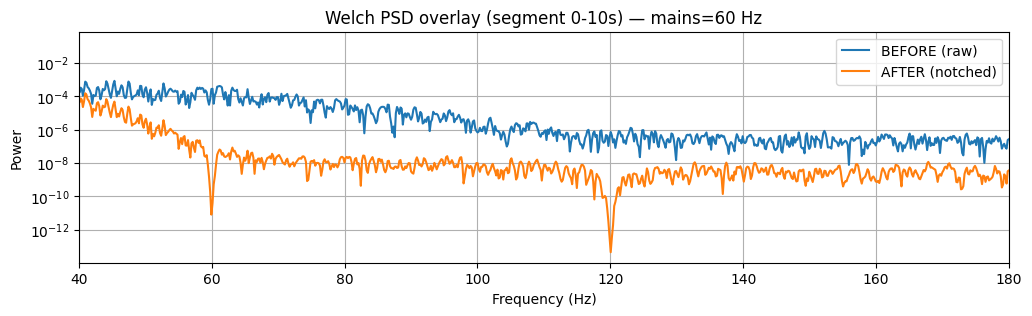

In [24]:
# (tuỳ chọn) chọn đoạn 10s để PSD ổn định & peak mains rõ hơn
start_s = 0
win_s = 10

i0 = int(start_s * fs)
i1 = int((start_s + win_s) * fs)

seg_before = x_raw[i0:i1]
seg_after  = x_notched[i0:i1]

# Welch PSD
nper = min(2048, len(seg_before))
f_b, P_b = welch(seg_before, fs=fs, nperseg=nper)
f_a, P_a = welch(seg_after,  fs=fs, nperseg=nper)

# Zoom quanh mains để thấy notch rõ nhất
mains = int(round(mains_used))
if mains == 50:
    xlim = (40, 70)   # bạn có thể đổi thành (45,55) nếu muốn zoom sát hơn
else:
    xlim = (40, 180)   # hoặc (55,65) để zoom sát 60 Hz

plt.figure(figsize=(12,3))
plt.semilogy(f_b, P_b, label="BEFORE (raw)")
plt.semilogy(f_a, P_a, label="AFTER (notched)")
plt.xlim(*xlim)
plt.title(f"Welch PSD overlay (segment {start_s}-{start_s+win_s}s) — mains={mains} Hz")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Power")
plt.grid(True)
plt.legend()
plt.show()

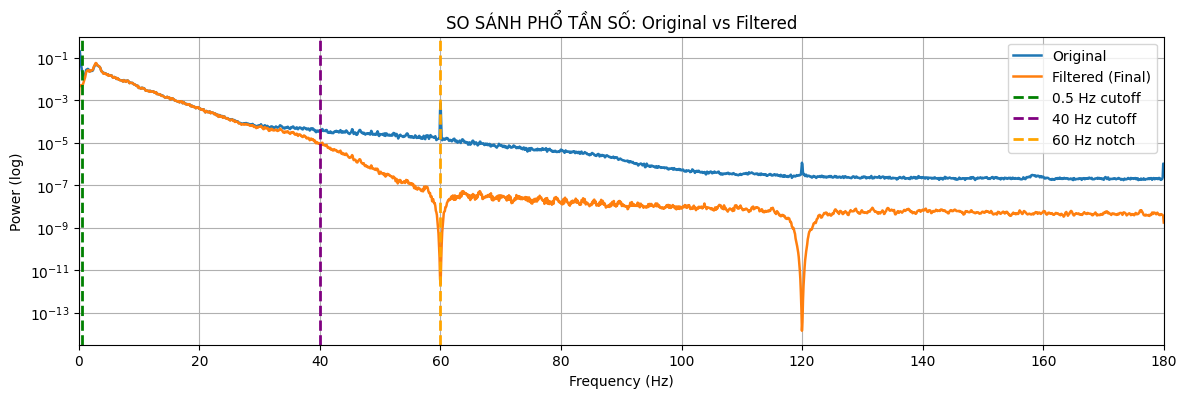

In [25]:
# CELL — So sánh phổ tần số: Original vs Filtered (màu khác nhau, không bị trùng)
# Dùng: x_raw, x_notched (hoặc x_final), fs, mains_used

def plot_spectrum_compare_colored(x_raw, x_final, fs,
                                  low_cut=0.5, high_cut=40.0, notch_hz=60,
                                  fmax=100, nperseg=4096):
    nper = int(min(nperseg, len(x_raw)))
    f1, P1 = welch(x_raw,   fs=fs, nperseg=nper)
    f2, P2 = welch(x_final, fs=fs, nperseg=nper)

    m1 = (f1 >= 0) & (f1 <= fmax)
    m2 = (f2 >= 0) & (f2 <= fmax)

    plt.figure(figsize=(14,4))

    # 2 đường phổ (màu khác)
    plt.semilogy(f1[m1], P1[m1], label="Original", linewidth=1.8)
    plt.semilogy(f2[m2], P2[m2], label="Filtered (Final)", linewidth=1.8)

    # vạch dọc cutoff/notch (màu khác + nét khác)
    plt.axvline(low_cut,  color="green",  linestyle="--", linewidth=2, label=f"{low_cut} Hz cutoff")
    plt.axvline(high_cut, color="purple", linestyle="--", linewidth=2, label=f"{high_cut} Hz cutoff")
    plt.axvline(notch_hz, color="orange", linestyle="--", linewidth=2, label=f"{int(round(notch_hz))} Hz notch")

    plt.title("SO SÁNH PHỔ TẦN SỐ: Original vs Filtered")
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Power (log)")
    plt.xlim(0, fmax)
    plt.grid(True)
    plt.legend()
    plt.show()

# Gọi hàm (x_final có thể là x_notched hoặc tín hiệu sau toàn bộ filter)
plot_spectrum_compare_colored(
    x_raw, x_notched, fs,
    low_cut=0.5, high_cut=40,
    notch_hz=mains_used, fmax=180
)


In [27]:
# CELL — Normalize (thuật toán)
import numpy as np

def zscore_normalize(x, eps=1e-12):
    """
    Z-score normalization:
    y = (x - mean(x)) / (std(x) + eps)
    Output: mean ~ 0, std ~ 1
    """
    x = np.asarray(x, dtype=float)
    mu = np.mean(x)
    sd = np.std(x) + eps
    return (x - mu) / sd

def minmax_normalize(x, eps=1e-12):
    """
    Min-max normalization:
    y = (x - min) / (max - min + eps)
    Output: nằm trong [0, 1]
    """
    x = np.asarray(x, dtype=float)
    mn, mx = np.min(x), np.max(x)
    return (x - mn) / (mx - mn + eps)

# --- CHỌN 1 KIỂU ---
x_norm = zscore_normalize(x_raw)   # hoặc: x_norm = minmax_normalize(x_raw)
print("After normalize:", "mean =", float(np.mean(x_norm)), "| std =", float(np.std(x_norm)))


After normalize: mean = 1.9589116653570762e-17 | std = 0.9999999999979817


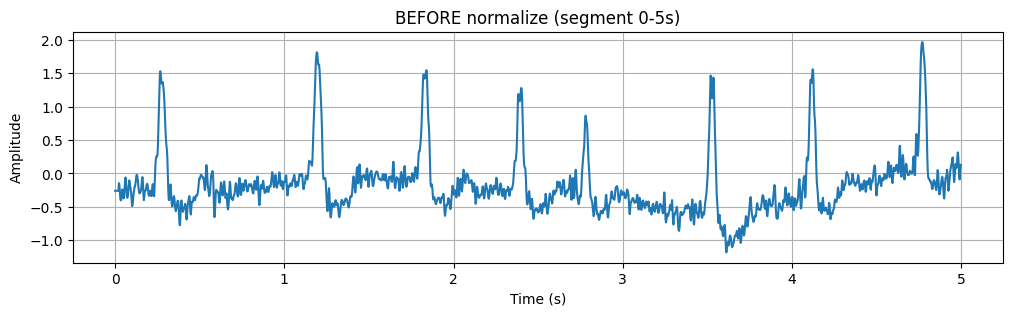

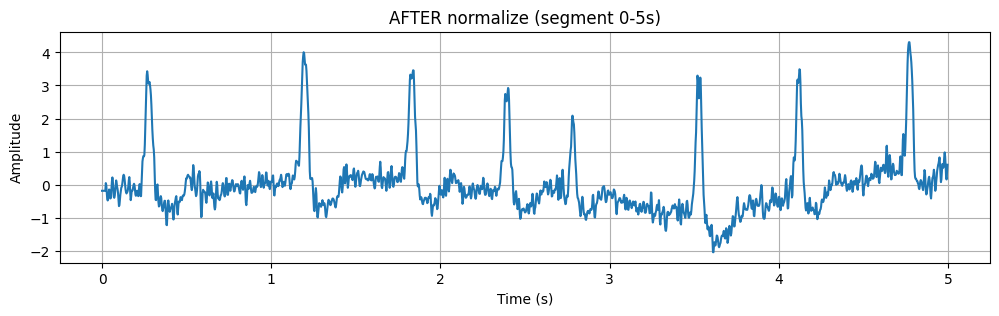

In [28]:
# CELL — Visualize BEFORE vs AFTER normalize (2 hình riêng)
import matplotlib.pyplot as plt
import numpy as np

def plot_segment(x, fs, start_s=0, win_s=5, title=""):
    i0 = int(start_s * fs)
    i1 = int((start_s + win_s) * fs)
    seg = x[i0:i1]
    t = np.arange(len(seg)) / fs + start_s
    plt.figure(figsize=(12,3))
    plt.plot(t, seg)
    plt.title(title)
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude")
    plt.grid(True)
    plt.show()

start_s = 0
win_s = 5

plot_segment(x_raw, fs, start_s, win_s, title=f"BEFORE normalize (segment {start_s}-{start_s+win_s}s)")
plot_segment(x_norm, fs, start_s, win_s, title=f"AFTER normalize (segment {start_s}-{start_s+win_s}s)")


In [ ]:
# normalize
def zscore_normalize(x, eps=1e-12):
    x = np.asarray(x, dtype=float)
    mu = np.mean(x)
    sd = np.std(x) + eps
    return (x - mu) / sd

Segment 0-1800s
  BEFORE: mean=-0.169549, std=0.495763, min=-4.305, max=3.640
  AFTER : mean=-0.000000, std=1.000000, min=-8.342, max=7.684


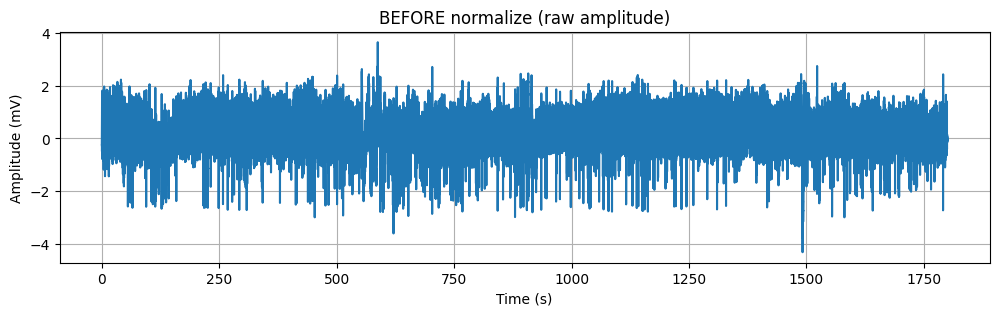

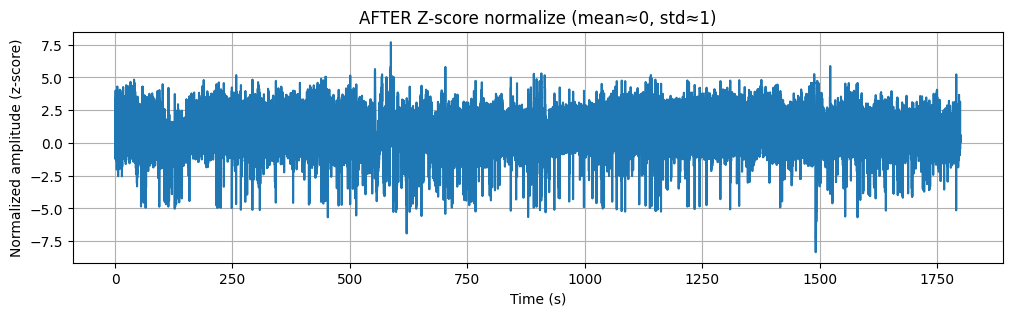

In [ ]:
def plot_before_after_zscore(x, fs, start_s=0, win_s=10):
    i0 = int(start_s * fs)
    i1 = int((start_s + win_s) * fs)
    seg = x[i0:i1]
    t = np.arange(len(seg)) / fs + start_s

    seg_z = zscore_normalize(seg)

    # print stats
    print(f"Segment {start_s}-{start_s+win_s}s")
    print(f"  BEFORE: mean={np.mean(seg):.6f}, std={np.std(seg):.6f}, min={np.min(seg):.3f}, max={np.max(seg):.3f}")
    print(f"  AFTER : mean={np.mean(seg_z):.6f}, std={np.std(seg_z):.6f}, min={np.min(seg_z):.3f}, max={np.max(seg_z):.3f}")
def plot_before_after_zscore(x, fs, start_s=0, win_s=10):
    i0 = int(start_s * fs)
    i1 = int((start_s + win_s) * fs)
    seg = x[i0:i1]
    t = np.arange(len(seg)) / fs + start_s

    seg_z = zscore_normalize(seg)    
# plot 2 hình riêng (rõ nhất)
    plt.figure(figsize=(12,3))
    plt.plot(t, seg)
    plt.title("BEFORE normalize (raw amplitude)")
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude (mV)")
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(12,3))
    plt.plot(t, seg_z)
    plt.title("AFTER Z-score normalize (mean≈0, std≈1)")
    plt.xlabel("Time (s)")
    plt.ylabel("Normalized amplitude (z-score)")
    plt.grid(True)
    plt.show()
    # ===== CHẠY =====
plot_before_after_zscore(x_raw, fs, start_s=0, win_s=1800)  # bạn đổi start_s theo đoạn muốn xem